# Glycemic-variable ablation: bar plots

Reads the `ablation_comparison.csv` produced by `ablation_runner_full.py` and `ablation_runner_no_cpeptide.py` (run via `run_ablation_full.sh` / `run_ablation_no_cpeptide.sh` on O2 first -- each is a full GridSearchCV sweep across 7 scenarios x 4 study groups, so this notebook has nothing to plot until those jobs finish) and plots insulin-prediction R², broken out **by study group**, for:

- the baseline (every covariate minus glycemic vars) vs. each variable added back on its own (TIR, CV, mean-of-nightly-means, MAGE, MODD, serum glucose + HbA1c together)
- the same comparison with C-peptide also excluded from the baseline

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

SCENARIO_LABELS = {
    '1_baseline_no_glycemic': 'Baseline\n(no glycemic vars)',
    '2_add_tir': '+ TIR',
    '3_add_cv': '+ CV',
    '4_add_mean_of_nightly_means': '+ Overnight mean\n(mean of nightly means)',
    '5_add_mage': '+ MAGE',
    '6_add_modd': '+ MODD',
    '7_add_glucose_hba1c': '+ Serum glucose\n+ HbA1c',
}
SCENARIO_ORDER = list(SCENARIO_LABELS.values())

# Validated categorical palette (references/palette.md in the dataviz skill),
# fixed order -- one hue per scenario, never reassigned/cycled.
SCENARIO_COLORS = dict(zip(SCENARIO_ORDER, [
    '#2a78d6',  # blue
    '#1baf7a',  # aqua
    '#eda100',  # yellow
    '#008300',  # green
    '#4a3aa7',  # violet
    '#e34948',  # red
    '#e87ba4',  # magenta
]))


def load_comparison(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found -- run the matching sbatch script in cgm_extraction_models/ first "
            "(run_ablation_full.sh or run_ablation_no_cpeptide.sh)."
        )
    comp = pd.read_csv(path)
    comp['scenario_label'] = comp['scenario'].map(SCENARIO_LABELS)
    return comp

## R² by study group and scenario -- full-covariate baseline

In [2]:
comp_full = load_comparison('results_full/ablation_comparison.csv')

def fmt(r2, se):
    return f'{r2:.3f} \u00b1 {se:.3f}'

comp_full['ElasticNet R2 (\u00b1 SE)'] = [fmt(r, s) for r, s in zip(comp_full['enet_r2'], comp_full['enet_r2_se'])]
comp_full['XGBoost R2 (\u00b1 SE)'] = [fmt(r, s) for r, s in zip(comp_full['xgb_r2'], comp_full['xgb_r2_se'])]

pretty_full = comp_full.pivot(index='study_group', columns='scenario_label',
                               values=['ElasticNet R2 (\u00b1 SE)', 'XGBoost R2 (\u00b1 SE)'])
pretty_full = pretty_full.reindex(columns=SCENARIO_ORDER, level=1)
pretty_full

ElasticNet R2 (± SE)  \
scenario_label                                     Baseline\n(no glycemic vars)   
study_group                                                                       
healthy                                                           0.741 ± 0.042   
insulin_dependent                                                 0.072 ± 0.165   
oral_medication_and_or_non_insulin_injectable_m...                0.681 ± 0.054   
pre_diabetes_lifestyle_controlled                                 0.716 ± 0.071   

                                                                   \
scenario_label                                              + TIR   
study_group                                                         
healthy                                             0.736 ± 0.042   
insulin_dependent                                   0.095 ± 0.160   
oral_medication_and_or_non_insulin_injectable_m...  0.681 ± 0.054   
pre_diabetes_lifestyle_controlled                   0.722 ± 0.068   

                                                                   \
scenario_label                                               + CV   
study_group                                                         
healthy                                             0.744 ± 0.043   
insulin_dependent                                   0.087 ± 0.166   
oral_medication_and_or_non_insulin_injectable_m...  0.681 ± 0.054   
pre_diabetes_lifestyle_controlled                   0.712 ± 0.072   

                                                                                              \
scenario_label                                     + Overnight mean\n(mean of nightly means)   
study_group                                                                                    
healthy                                                                        0.737 ± 0.042   
insulin_dependent                                                              0.074 ± 0.176   
oral_medication_and_or_non_insulin_injectable_m...                             0.680 ± 0.055   
pre_diabetes_lifestyle_controlled                                              0.713 ± 0.074   

                                                                   \
scenario_label                                             + MAGE   
study_group                                                         
healthy                                             0.735 ± 0.042   
insulin_dependent                                   0.108 ± 0.177   
oral_medication_and_or_non_insulin_injectable_m...  0.674 ± 0.040   
pre_diabetes_lifestyle_controlled                   0.728 ± 0.069   

                                                                   \
scenario_label                                             + MODD   
study_group                                                         
healthy                                             0.734 ± 0.043   
insulin_dependent                                   0.142 ± 0.168   
oral_medication_and_or_non_insulin_injectable_m...  0.675 ± 0.040   
pre_diabetes_lifestyle_controlled                   0.721 ± 0.071   

                                                                             \
scenario_label                                     + Serum glucose\n+ HbA1c   
study_group                                                                   
healthy                                                       0.754 ± 0.045   
insulin_dependent                                             0.095 ± 0.162   
oral_medication_and_or_non_insulin_injectable_m...            0.685 ± 0.037   
pre_diabetes_lifestyle_controlled                             0.712 ± 0.080   

                                                              XGBoost R2 (± SE)  \
scenario_label                                     Baseline\n(no glycemic vars)   
study_group                                                                       
healthy                                                          

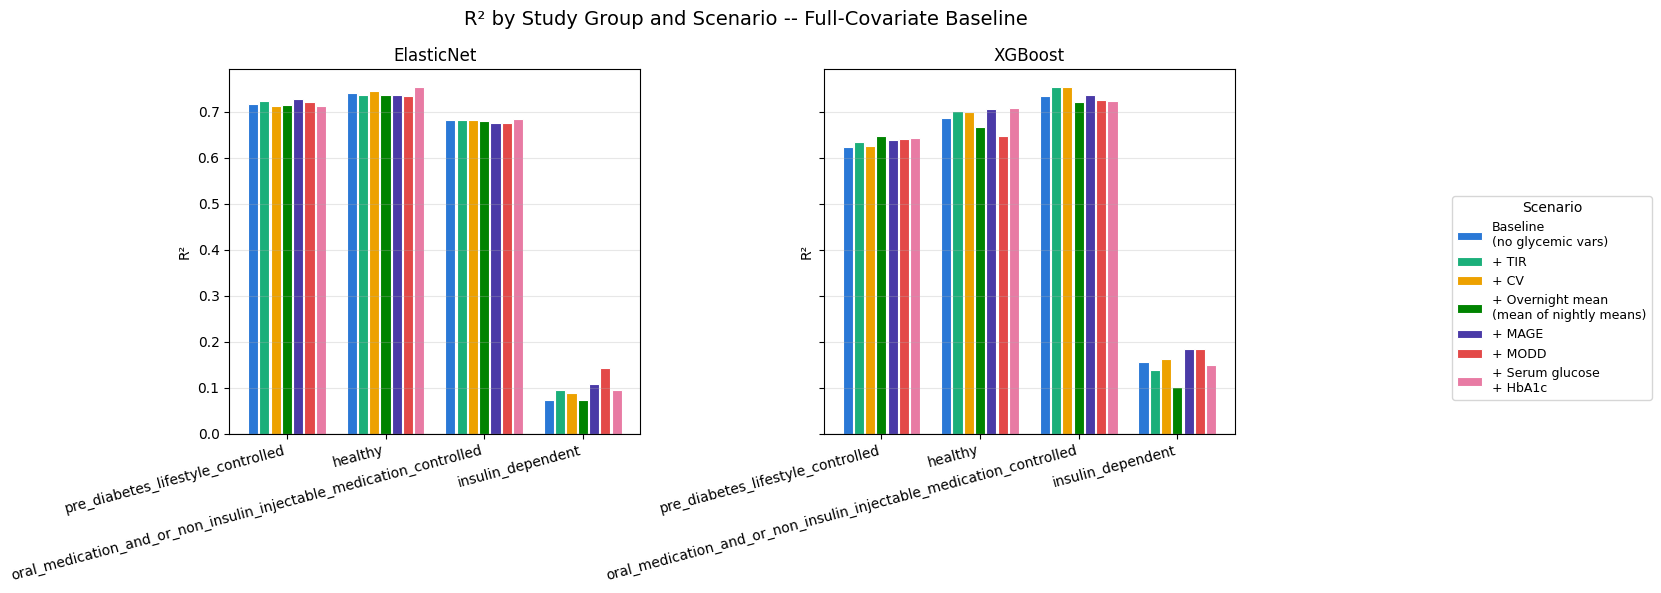

In [3]:
def plot_r2_bars(comp, title, save_path):
    """Grouped bar chart of R2 by study_group, dodged by scenario, one subplot per model."""
    study_groups = comp['study_group'].unique()
    scenarios = [s for s in SCENARIO_ORDER if s in comp['scenario_label'].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    n_scenarios = len(scenarios)
    group_width = 0.8
    bar_width = group_width / n_scenarios

    for ax, model, r2_col in zip(
        axes,
        ['ElasticNet', 'XGBoost'],
        ['enet_r2', 'xgb_r2'],
    ):
        x = np.arange(len(study_groups))

        # dodge bars side-by-side per scenario so every color stays fully
        # visible, even when R2 values are nearly identical across scenarios
        for i, scenario in enumerate(scenarios):
            offset = (i - (n_scenarios - 1) / 2) * bar_width
            sub = comp[comp['scenario_label'] == scenario].set_index('study_group').reindex(study_groups)
            ax.bar(
                x + offset, sub[r2_col], width=bar_width * 0.9,
                color=SCENARIO_COLORS[scenario],
                edgecolor='white', linewidth=0.8,
                label=scenario,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(study_groups, rotation=15, ha='right')
        ax.set_ylabel('R²')
        ax.set_title(model)
        ax.axhline(0, color='#52514e', linewidth=0.8)
        ax.grid(axis='y', alpha=0.3, zorder=0)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title='Scenario',
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        fontsize=9,
    )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.86, 1])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_r2_bars(
    comp_full,
    'R² by Study Group and Scenario -- Full-Covariate Baseline',
    'results_full/r2_comparison_by_study_group.png',
)

## R² by study group and scenario -- baseline excluding C-peptide

In [4]:
comp_noc = load_comparison('results_no_cpeptide/ablation_comparison.csv')

comp_noc['ElasticNet R2 (\u00b1 SE)'] = [fmt(r, s) for r, s in zip(comp_noc['enet_r2'], comp_noc['enet_r2_se'])]
comp_noc['XGBoost R2 (\u00b1 SE)'] = [fmt(r, s) for r, s in zip(comp_noc['xgb_r2'], comp_noc['xgb_r2_se'])]

pretty_noc = comp_noc.pivot(index='study_group', columns='scenario_label',
                             values=['ElasticNet R2 (\u00b1 SE)', 'XGBoost R2 (\u00b1 SE)'])
pretty_noc = pretty_noc.reindex(columns=SCENARIO_ORDER, level=1)
pretty_noc

ElasticNet R2 (± SE)  \
scenario_label                                     Baseline\n(no glycemic vars)   
study_group                                                                       
healthy                                                           0.224 ± 0.050   
insulin_dependent                                                 0.036 ± 0.122   
oral_medication_and_or_non_insulin_injectable_m...                0.155 ± 0.028   
pre_diabetes_lifestyle_controlled                                 0.118 ± 0.030   

                                                                   \
scenario_label                                              + TIR   
study_group                                                         
healthy                                             0.224 ± 0.050   
insulin_dependent                                   0.036 ± 0.122   
oral_medication_and_or_non_insulin_injectable_m...  0.165 ± 0.032   
pre_diabetes_lifestyle_controlled                   0.118 ± 0.030   

                                                                   \
scenario_label                                               + CV   
study_group                                                         
healthy                                             0.228 ± 0.051   
insulin_dependent                                   0.036 ± 0.122   
oral_medication_and_or_non_insulin_injectable_m...  0.155 ± 0.028   
pre_diabetes_lifestyle_controlled                   0.118 ± 0.030   

                                                                                              \
scenario_label                                     + Overnight mean\n(mean of nightly means)   
study_group                                                                                    
healthy                                                                        0.198 ± 0.051   
insulin_dependent                                                              0.048 ± 0.117   
oral_medication_and_or_non_insulin_injectable_m...                             0.154 ± 0.030   
pre_diabetes_lifestyle_controlled                                              0.118 ± 0.031   

                                                                   \
scenario_label                                             + MAGE   
study_group                                                         
healthy                                             0.196 ± 0.052   
insulin_dependent                                   0.050 ± 0.116   
oral_medication_and_or_non_insulin_injectable_m...  0.155 ± 0.029   
pre_diabetes_lifestyle_controlled                   0.122 ± 0.029   

                                                                   \
scenario_label                                             + MODD   
study_group                                                         
healthy                                             0.197 ± 0.053   
insulin_dependent                                   0.066 ± 0.118   
oral_medication_and_or_non_insulin_injectable_m...  0.154 ± 0.029   
pre_diabetes_lifestyle_controlled                   0.118 ± 0.031   

                                                                             \
scenario_label                                     + Serum glucose\n+ HbA1c   
study_group                                                                   
healthy                                                       0.346 ± 0.049   
insulin_dependent                                             0.037 ± 0.125   
oral_medication_and_or_non_insulin_injectable_m...            0.241 ± 0.031   
pre_diabetes_lifestyle_controlled                             0.082 ± 0.273   

                                                              XGBoost R2 (± SE)  \
scenario_label                                     Baseline\n(no glycemic vars)   
study_group                                                                       
healthy                                                          

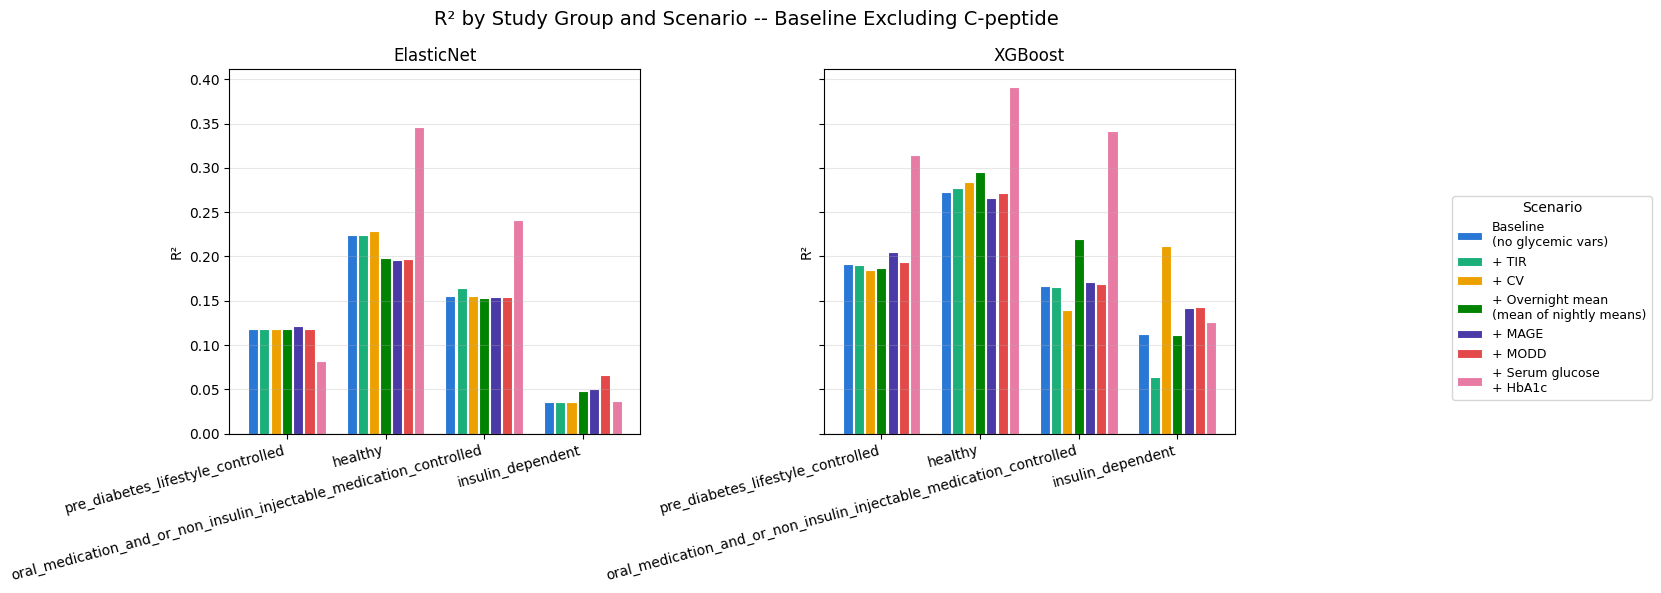

In [5]:
plot_r2_bars(
    comp_noc,
    'R\u00b2 by Study Group and Scenario -- Baseline Excluding C-peptide',
    'results_no_cpeptide/r2_comparison_by_study_group.png',
)

## R² improvement over baseline (Δ R²), by study group

Same data, re-expressed as *how much better than the no-glycemic baseline* each added variable makes the model, per study group. This isolates each variable's individual contribution rather than the absolute R² level.

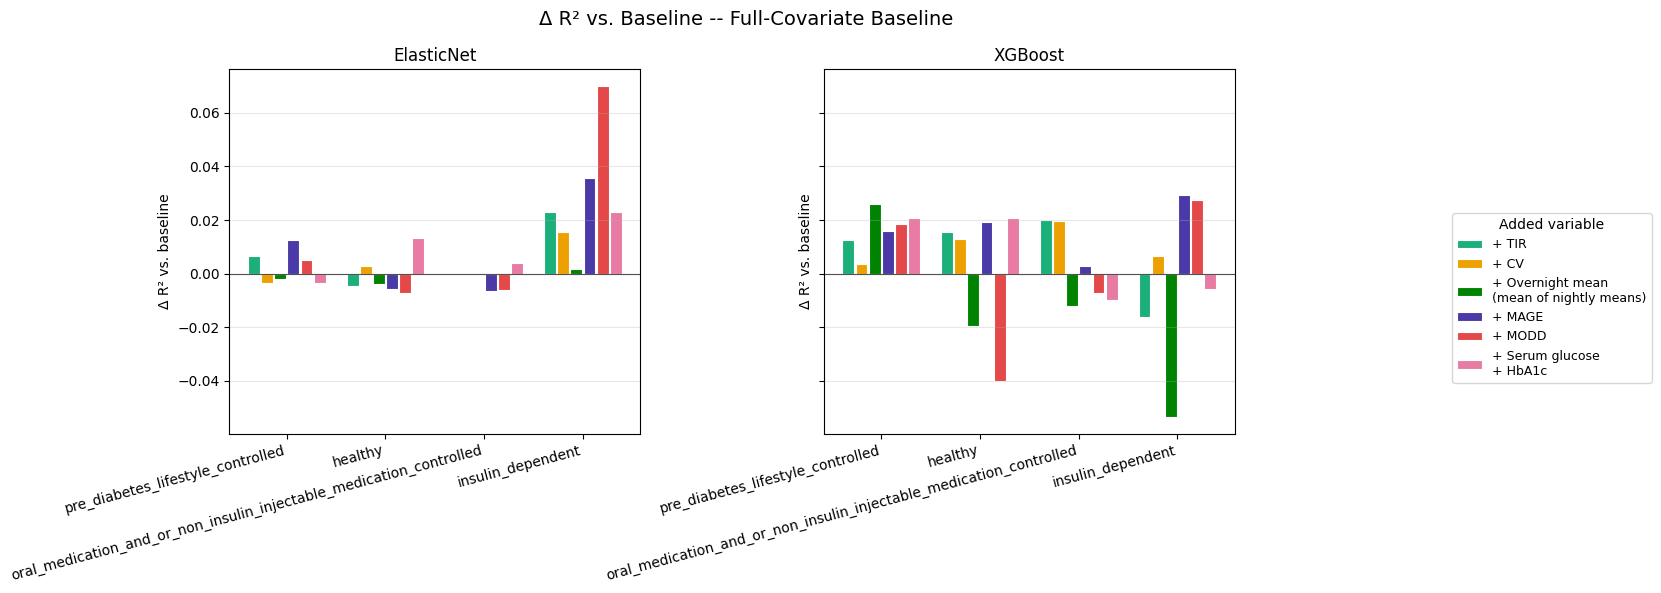

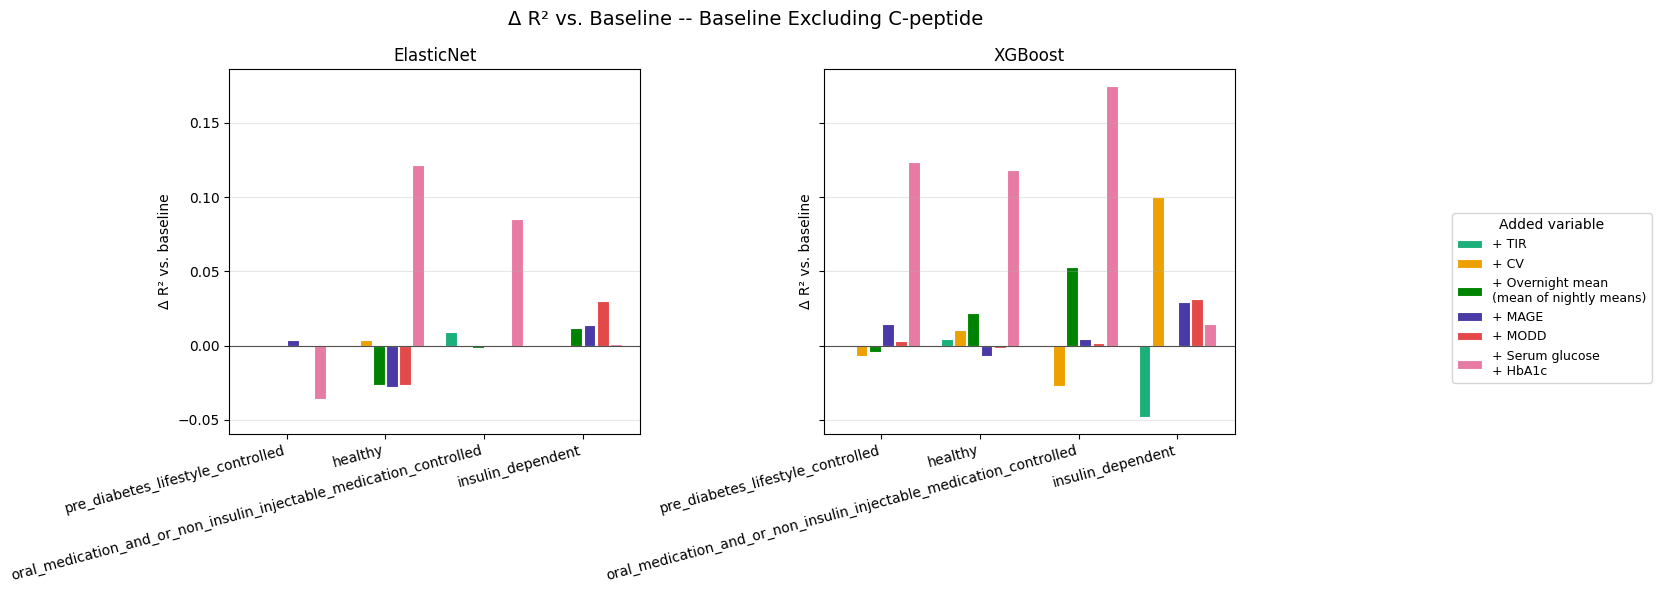

In [6]:
def plot_delta_bars(comp, title, save_path):
    """Grouped bar chart of R2 minus the baseline scenario's R2, by study_group, dodged by added variable."""
    added_scenarios = [s for s in SCENARIO_ORDER[1:] if s in comp['scenario_label'].unique()]
    study_groups = comp['study_group'].unique()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    n_scenarios = len(added_scenarios)
    group_width = 0.8
    bar_width = group_width / n_scenarios

    for ax, model, r2_col in zip(axes, ['ElasticNet', 'XGBoost'], ['enet_r2', 'xgb_r2']):
        baseline = (
            comp[comp['scenario_label'] == SCENARIO_ORDER[0]]
            .set_index('study_group')[r2_col]
            .reindex(study_groups)
        )
        x = np.arange(len(study_groups))

        for i, scenario in enumerate(added_scenarios):
            offset = (i - (n_scenarios - 1) / 2) * bar_width
            sub = comp[comp['scenario_label'] == scenario].set_index('study_group').reindex(study_groups)
            delta = sub[r2_col] - baseline
            ax.bar(
                x + offset, delta, width=bar_width * 0.9,
                color=SCENARIO_COLORS[scenario],
                edgecolor='white', linewidth=0.8,
                label=scenario,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(study_groups, rotation=15, ha='right')
        ax.set_ylabel('\u0394 R\u00b2 vs. baseline')
        ax.set_title(model)
        ax.axhline(0, color='#52514e', linewidth=0.8)
        ax.grid(axis='y', alpha=0.3, zorder=0)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title='Added variable',
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        fontsize=9,
    )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.86, 1])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_delta_bars(
    comp_full,
    '\u0394 R\u00b2 vs. Baseline -- Full-Covariate Baseline',
    'results_full/delta_r2_by_study_group.png',
)
plot_delta_bars(
    comp_noc,
    '\u0394 R\u00b2 vs. Baseline -- Baseline Excluding C-peptide',
    'results_no_cpeptide/delta_r2_by_study_group.png',
)